<a href="https://colab.research.google.com/github/knishaa01/Manufacturing-Quality-Production-Analysis/blob/main/Python_DataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

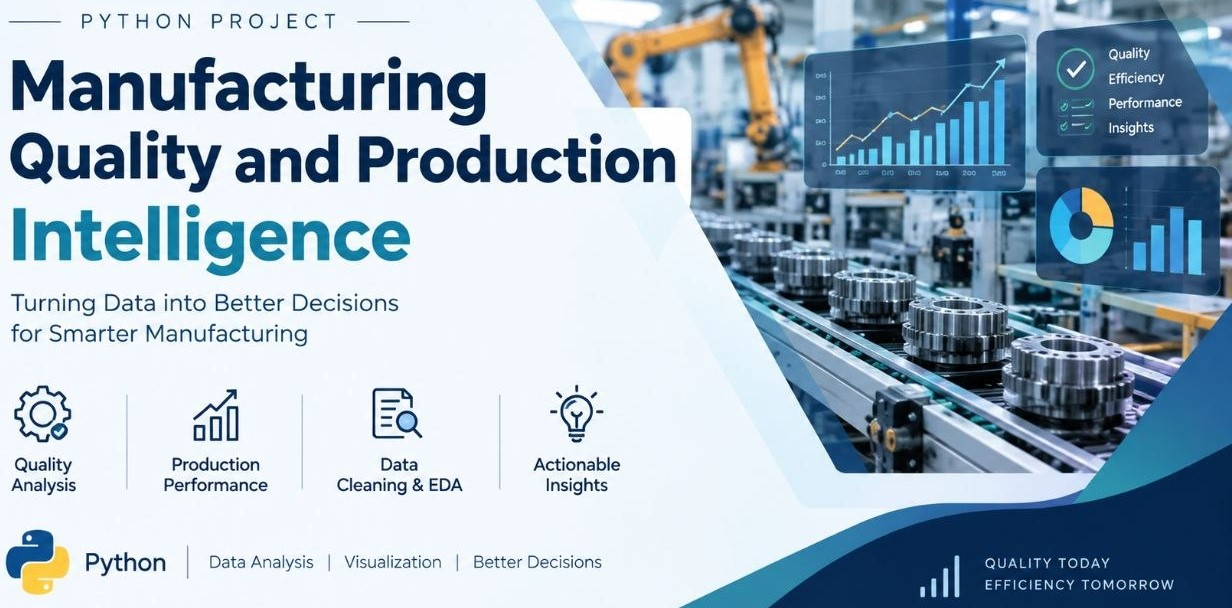

# Manufacturing Quality & Production Intelligence

**Project Objectives**

Analyze manufacturing production and quality data to identify:

*   Production efficiency
*   Quality performance
*   Scrap and rework
*   Defect patterns
*   Machine/process-related issues
*   Plant/line/shift performance
*   Cost impact
*   Operational relationships
*   Statistically significant quality differences

**Business Problem**

A manufacturing company wants to understand why some production lines, plants, shifts, or operating conditions produce more defects and scrap than others.

Management wants answers to questions such as:

*   Defect Reduction
*   Quality Optimization
*   Scrap & Rework Control
*   Plant & Line Performance
*   Shift & Machine Analysis
*   Material Quality Monitoring
*   Process Optimization
*   Cost & Cycle Time Reduction
*   Warranty Risk Analysis
*   Quality Trend Monitoring

### **1. Import Libraries**

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pandas → data loading, cleaning and analysis

numpy → numerical operations

matplotlib → visualization

seaborn → analytical/statistical charts


### **2. Load Dataset**

In [153]:
df = pd.read_csv('/content/sample_data/manufacturing_quality_decisions_10000.csv')

In [154]:
print("Rows",df.shape[0])
print("Coulmns",df.shape[1])

Rows 10000
Coulmns 23


Description:
This loads the manufacturing CSV
file into a Pandas DataFrame and confirms the number of records and columns.

Expected result:

*   Rows = 10,000
*   Columns = 23



### **3. View the Dataset**

In [155]:
print(df.head())

  event_id             event_ts    plant    line  shift machine_id  \
0  M200000  2025-08-27 17:15:31  plant_1  line_A    day      MC104   
1  M200001  2025-11-09 16:28:50  plant_1  line_A  swing      MC158   
2  M200002  2025-12-20 06:18:01  plant_1  line_D  night      MC144   
3  M200003  2025-12-06 12:38:46  plant_2  line_B  night      MC108   
4  M200004  2025-07-31 07:28:14  plant_1  line_C    day      MC113   

  operator_id  machine_age_yrs material_grade  temp_c  ...  defect_type  \
0      OP1009             1.55        grade_B     5.9  ...         none   
1      OP1419             1.98        grade_B    11.2  ...         none   
2      OP1042             0.20        grade_B    17.8  ...         none   
3      OP1013             0.90        grade_B    12.9  ...         none   
4      OP1312             1.92        grade_A    11.7  ...         none   

   defect_severity_0to3 decision_rework rework_time_min  final_pass  scrap  \
0                     0               0           

Description:
Displays the first five records to understand how the manufacturing data is structured.

In [156]:
print(df.tail())

     event_id             event_ts    plant    line  shift machine_id  \
9995  M209995  2025-11-04 19:38:29  plant_3  line_A  swing      MC153   
9996  M209996  2025-11-17 11:01:43  plant_1  line_B  swing      MC147   
9997  M209997  2025-11-23 17:27:54  plant_2  line_A    day      MC141   
9998  M209998  2025-07-18 06:56:55  plant_1  line_C    day      MC116   
9999  M209999  2026-01-01 22:24:58  plant_1  line_D  swing      MC115   

     operator_id  machine_age_yrs material_grade  temp_c  ...  defect_type  \
9995      OP1105             7.76        grade_C    11.4  ...         none   
9996      OP1449             4.63        grade_A     9.0  ...         none   
9997      OP1360             4.21        grade_A    10.6  ...         none   
9998      OP1399             7.31        grade_B    15.3  ...         none   
9999      OP1161             8.56        grade_A    17.4  ...         none   

      defect_severity_0to3 decision_rework rework_time_min  final_pass  scrap  \
9995       

Description:
Displays the last five records and helps verify the end of the dataset.

### **4. Check Column Names**

In [157]:
print(df.columns.tolist())

['event_id', 'event_ts', 'plant', 'line', 'shift', 'machine_id', 'operator_id', 'machine_age_yrs', 'material_grade', 'temp_c', 'humidity_pct', 'process_speed_units_hr', 'inspection_method', 'defect_type', 'defect_severity_0to3', 'decision_rework', 'rework_time_min', 'final_pass', 'scrap', 'total_cycle_time_min', 'energy_kwh', 'cost_usd', 'warranty_claim_90d']


In [158]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_id                10000 non-null  object 
 1   event_ts                10000 non-null  object 
 2   plant                   10000 non-null  object 
 3   line                    10000 non-null  object 
 4   shift                   10000 non-null  object 
 5   machine_id              10000 non-null  object 
 6   operator_id             10000 non-null  object 
 7   machine_age_yrs         10000 non-null  float64
 8   material_grade          10000 non-null  object 
 9   temp_c                  10000 non-null  float64
 10  humidity_pct            10000 non-null  float64
 11  process_speed_units_hr  10000 non-null  float64
 12  inspection_method       10000 non-null  object 
 13  defect_type             10000 non-null  object 
 14  defect_severity_0to3    10000 non-null 

Description:
Displays all available columns in the dataset.

### **5. Check Data Types**

In [159]:
print(df.dtypes)

event_id                   object
event_ts                   object
plant                      object
line                       object
shift                      object
machine_id                 object
operator_id                object
machine_age_yrs           float64
material_grade             object
temp_c                    float64
humidity_pct              float64
process_speed_units_hr    float64
inspection_method          object
defect_type                object
defect_severity_0to3        int64
decision_rework             int64
rework_time_min           float64
final_pass                  int64
scrap                       int64
total_cycle_time_min      float64
energy_kwh                float64
cost_usd                  float64
warranty_claim_90d          int64
dtype: object


Description:
Checks whether each column has the correct data type.

### **6. Convert Date Column**

In [160]:
df['event_ts'] = pd.to_datetime(df["event_ts"])

print(df['event_ts'].dtype)

datetime64[ns]


Description:
Converts event_ts from text into a proper datetime format so that time-based analysis can be performed.

### **7. Check Missing Values**

In [161]:
missing_values = df.isnull().sum()

print(missing_values)

event_id                  0
event_ts                  0
plant                     0
line                      0
shift                     0
machine_id                0
operator_id               0
machine_age_yrs           0
material_grade            0
temp_c                    0
humidity_pct              0
process_speed_units_hr    0
inspection_method         0
defect_type               0
defect_severity_0to3      0
decision_rework           0
rework_time_min           0
final_pass                0
scrap                     0
total_cycle_time_min      0
energy_kwh                0
cost_usd                  0
warranty_claim_90d        0
dtype: int64


Description:
Checks every column for missing values.

In [162]:
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 0


### **8. Check Duplicate Records**

In [163]:
duplicates = df.duplicated().sum()

print("Duplicate rows:",duplicates)

Duplicate rows: 0


Description:
Checks whether the dataset contains completely duplicated records.

### **9. Check Event ID Uniqueness**

In [164]:
print("Total Event IDs:",df['event_id'].nunique())
print("Total Rows:",len(df))

Total Event IDs: 10000
Total Rows: 10000


Description:
Checks whether every manufacturing event has a unique identifier.

### **10. Basic Statistical Analysis**

In [165]:
print(df.describe())

                            event_ts  machine_age_yrs        temp_c  \
count                          10000     10000.000000  10000.000000   
mean   2025-10-07 22:38:19.018800128         6.037194     12.631810   
min              2025-07-01 00:08:48         0.200000      5.000000   
25%       2025-08-19 17:34:36.500000         3.970000      9.300000   
50%              2025-10-08 13:47:03         6.070000     12.200000   
75%              2025-11-25 13:23:37         8.040000     15.800000   
max              2026-01-14 23:52:27        17.980000     28.100000   
std                              NaN         2.931235      4.359551   

       humidity_pct  process_speed_units_hr  defect_severity_0to3  \
count  10000.000000            10000.000000          10000.000000   
mean      52.139380              121.867890              0.289400   
min       18.200000               60.000000              0.000000   
25%       41.900000              104.900000              0.000000   
50%       52.80

Description:
Provides statistical information such as:
*   count
*   mean
*   standard deviation
*   minimum
*   maximum
*   quatiles

for numerical columns.

### **11. Check Categorial Columns**

In [166]:
categorial_columns = [
    'plant',
    'line',
    'shift',
    'material_grade',
    'inspection_method',
    'defect_type'
]

for col in categorial_columns:
  print('/n',col)
  print(df[col].value_counts())

/n plant
plant
plant_1    4459
plant_2    3529
plant_3    2012
Name: count, dtype: int64
/n line
line
line_D    2588
line_C    2514
line_A    2482
line_B    2416
Name: count, dtype: int64
/n shift
shift
day      4785
swing    3248
night    1967
Name: count, dtype: int64
/n material_grade
material_grade
grade_A    4981
grade_B    3459
grade_C    1560
Name: count, dtype: int64
/n inspection_method
inspection_method
vision    3989
manual    3964
sensor    2047
Name: count, dtype: int64
/n defect_type
defect_type
none             8403
dimension         332
finish            324
contamination     320
crack             311
scratch           310
Name: count, dtype: int64


Description:
This checks the distribution of important categorical manufacturing variables.

### **12. Validate Binary Columns**

In [167]:
binary_columns = [
    'decision_rework',
    'final_pass',
    'scrap',
    'warranty_claim_90d'
]

# print(df[binary_columns].value_counts())
for col in binary_columns:
  print(col,':',sorted(df[col].unique()))

decision_rework : [np.int64(0), np.int64(1)]
final_pass : [np.int64(0), np.int64(1)]
scrap : [np.int64(0), np.int64(1)]
warranty_claim_90d : [np.int64(0), np.int64(1)]


Description:
These columns should contain binary values such as 0 and 1. This check confirms their actual values before analysis.

### **13. Validate defect Severity**

In [168]:
invalid_severity = df[
    (df['defect_severity_0to3']<0) |
    (df['defect_severity_0to3']>3)
]

print('Invalid severity records:',len(invalid_severity))

Invalid severity records: 0


Description:
defect_severity_0to3 should remain between 0 and 3. This identifies invalid values.

### **14. Create Defect Flag**

In [169]:
df['defect_flag'] = (
    df['defect_type'] != 'None'
).astype(int)

print(df[['defect_type']].head())

  defect_type
0        none
1        none
2        none
3        none
4        none


Description:
Creates a new column:

*   1 → a defect exists
*   0 → no defect

This makes defect-rate calculations easier.

### **15. Create Failure Flag**

In [170]:
df['failure_flag'] = (
    df['final_pass'] == 0
).astype(int)

print(df[['final_pass','failure_flag']].head())

   final_pass  failure_flag
0           1             0
1           1             0
2           1             0
3           1             0
4           1             0


Description:
Creates a flag identifying products that failed final inspection.

### **16. Extract Date Information**

In [171]:
df['year'] = df['event_ts'].dt.year

df['month'] = df['event_ts'].dt.to_period('M').astype(str)

df['day_of_week'] = df['event_ts'].dt.day_name()

df['hour']  = df['event_ts'].dt.hour

print(df[['event_ts','year','month','day_of_week','hour']])

                event_ts  year    month day_of_week  hour
0    2025-08-27 17:15:31  2025  2025-08   Wednesday    17
1    2025-11-09 16:28:50  2025  2025-11      Sunday    16
2    2025-12-20 06:18:01  2025  2025-12    Saturday     6
3    2025-12-06 12:38:46  2025  2025-12    Saturday    12
4    2025-07-31 07:28:14  2025  2025-07    Thursday     7
...                  ...   ...      ...         ...   ...
9995 2025-11-04 19:38:29  2025  2025-11     Tuesday    19
9996 2025-11-17 11:01:43  2025  2025-11      Monday    11
9997 2025-11-23 17:27:54  2025  2025-11      Sunday    17
9998 2025-07-18 06:56:55  2025  2025-07      Friday     6
9999 2026-01-01 22:24:58  2026  2026-01    Thursday    22

[10000 rows x 5 columns]


Description:
Creates useful time features for:

*   yearly analysis
*   monthly trends
*   weekday analysis
*   production-hour analysis

### **17. Overall Manufacturing KPIs**

In [172]:
total_events = len(df)

defect_rate = df['defect_flag'].mean() * 100

pass_rate = df['final_pass'].mean() * 100

scrap_rate = df['scrap'].mean() * 100

rework_rate = df['decision_rework'].mean() * 100

warranty_claim_rate = df['warranty_claim_90d'].mean() * 100

average_cycle_time = df['total_cycle_time_min'].mean()

average_energy = df['energy_kwh'].mean()

average_cost = df['cost_usd'].mean()

print('total_event:',total_events)
print('Defect Rate:',round(defect_rate,2),'%')
print('Final Pass Rate:',round(pass_rate,2),'%')
print('Scrap Rate:',round(scrap_rate,2),'%')
print('Rework Rate:',round(rework_rate,2),'%')
print('Warranty claim Rate:',round(warranty_claim_rate,2),'%')
print('Average Cycle Time:',round(average_cycle_time,2))
print('Average Energy:',round(average_energy,2))
print('Average Cost:',round(average_cost,2))

total_event: 10000
Defect Rate: 100.0 %
Final Pass Rate: 87.61 %
Scrap Rate: 2.48 %
Rework Rate: 24.34 %
Warranty claim Rate: 1.25 %
Average Cycle Time: 34.52
Average Energy: 1.42
Average Cost: 29.04


Description:
This calculates the main manufacturing KPIs that a company can use to monitor production quality and operational performance.

### **18. Defect Type Analysis**

In [173]:
defect_analysis = (
    df['defect_type'].value_counts()
)
print(defect_analysis)

defect_type
none             8403
dimension         332
finish            324
contamination     320
crack             311
scratch           310
Name: count, dtype: int64


Description:
Counts how frequently each defect type occurs.

### **19. Actual Defect Analysis**

In [174]:
actual_defects = df[df['defect_type'] != None]

defect_type_analysis = (actual_defects['defect_type'].value_counts())

print(defect_type_analysis)

defect_type
none             8403
dimension         332
finish            324
contamination     320
crack             311
scratch           310
Name: count, dtype: int64


Description:
Removes the none category and analyses only actual manufacturing defects.

### **20. Defect Percentage**

In [175]:
defect_percentage = (defect_type_analysis / len(actual_defects)) * 100

print(defect_percentage.round(2))

defect_type
none             84.03
dimension         3.32
finish            3.24
contamination     3.20
crack             3.11
scratch           3.10
Name: count, dtype: float64


Description:
Calculates the percentage contribution of each actual defect type.

### **21. Quality analysis by plant**

In [176]:
plant_analysis = df.groupby('plant').agg(
    events=('event_id','count'),
    defect_rate=('defect_flag','mean'),
    pass_rate=('final_pass','mean'),
    scrap_rate=('scrap','mean'),
    rework_rate=('decision_rework','mean'),
    warranty_rate=('warranty_claim_90d','mean'),
    average_cost=('cost_usd','mean'),
    average_cycle_time=('total_cycle_time_min','mean')
)

rate_column = [
    'defect_rate',
    'pass_rate',
    'scrap_rate',
    'rework_rate',
    'warranty_rate'
]
plant_analysis[rate_column] *= 100

print(plant_analysis.round(2))

         events  defect_rate  pass_rate  scrap_rate  rework_rate  \
plant                                                              
plant_1    4459        100.0      87.51        2.62        23.46   
plant_2    3529        100.0      87.99        2.21        25.13   
plant_3    2012        100.0      87.18        2.63        24.90   

         warranty_rate  average_cost  average_cycle_time  
plant                                                     
plant_1           1.50         29.15               34.51  
plant_2           1.08         28.86               34.56  
plant_3           0.99         29.14               34.47  


Description:
Compares manufacturing quality and operational KPIs across different plants.

### **22. Quality Analysis by production Line**

In [177]:
line_analysis = df.groupby("line").agg(
    events=("event_id", "count"),
    defect_rate=("defect_flag", "mean"),
    pass_rate=("final_pass", "mean"),
    scrap_rate=("scrap", "mean"),
    rework_rate=("decision_rework", "mean"),
    warranty_rate=("warranty_claim_90d", "mean"),
    average_cost=("cost_usd", "mean"),
    average_cycle_time=("total_cycle_time_min", "mean")
)

line_analysis[rate_column] *= 100

print(line_analysis.round(2))

        events  defect_rate  pass_rate  scrap_rate  rework_rate  \
line                                                              
line_A    2482        100.0      87.67        2.10        24.25   
line_B    2416        100.0      88.41        2.40        24.79   
line_C    2514        100.0      86.99        2.59        23.83   
line_D    2588        100.0      87.40        2.82        24.50   

        warranty_rate  average_cost  average_cycle_time  
line                                                     
line_A           1.29         28.12               33.74  
line_B           0.95         28.66               34.06  
line_C           1.39         28.35               33.59  
line_D           1.35         30.96               36.61  


Description:
Identifies differences in quality, scrap, rework and production performance between production lines.

### **23. Quality Analysis By Shift**

In [178]:
shift_analysis = df.groupby("shift").agg(
    events=("event_id", "count"),
    defect_rate=("defect_flag", "mean"),
    pass_rate=("final_pass", "mean"),
    scrap_rate=("scrap", "mean"),
    rework_rate=("decision_rework", "mean"),
    warranty_rate=("warranty_claim_90d", "mean"),
    average_cost=("cost_usd", "mean"),
    average_cycle_time=("total_cycle_time_min", "mean")
)

shift_analysis[rate_column] *= 100

print(shift_analysis.round(2))

       events  defect_rate  pass_rate  scrap_rate  rework_rate  warranty_rate  \
shift                                                                           
day      4785        100.0      87.92        2.32        24.26           1.09   
night    1967        100.0      86.73        2.80        24.91           1.53   
swing    3248        100.0      87.68        2.52        24.11           1.32   

       average_cost  average_cycle_time  
shift                                    
day           29.01               34.59  
night         29.61               34.97  
swing         28.75               34.14  


Description:
Compares quality and operational performance between day, swing and night shifts.

### **24. Material Grade Analysis**

In [179]:
material_analysis = df.groupby("material_grade").agg(
    events=("event_id", "count"),
    defect_rate=("defect_flag", "mean"),
    pass_rate=("final_pass", "mean"),
    scrap_rate=("scrap", "mean"),
    rework_rate=("decision_rework", "mean"),
    warranty_rate=("warranty_claim_90d", "mean"),
    average_cost=("cost_usd", "mean"),
    average_cycle_time=("total_cycle_time_min", "mean")
)

material_analysis[rate_column] *= 100

print(material_analysis.round(2))

                events  defect_rate  pass_rate  scrap_rate  rework_rate  \
material_grade                                                            
grade_A           4981        100.0      88.09        2.07        23.15   
grade_B           3459        100.0      87.42        2.78        25.67   
grade_C           1560        100.0      86.47        3.14        25.19   

                warranty_rate  average_cost  average_cycle_time  
material_grade                                                   
grade_A                  1.12         27.93               33.88  
grade_B                  1.19         29.73               34.99  
grade_C                  1.79         31.07               35.54  


Description:
Shows whether manufacturing quality and cost vary across different material grades.

### **25. Inspectiom Mathod Analysis**

In [180]:
inspection_analysis = df.groupby("inspection_method").agg(
    events=("event_id", "count"),
    defect_rate=("defect_flag", "mean"),
    pass_rate=("final_pass", "mean"),
    scrap_rate=("scrap", "mean"),
    rework_rate=("decision_rework", "mean"),
    warranty_rate=("warranty_claim_90d", "mean"),
    average_cost=("cost_usd", "mean"),
    average_cycle_time=("total_cycle_time_min", "mean")
)

inspection_analysis[rate_column] *= 100

print(inspection_analysis.round(2))

                   events  defect_rate  pass_rate  scrap_rate  rework_rate  \
inspection_method                                                            
manual               3964        100.0      87.24        2.77        26.41   
sensor               2047        100.0      88.91        1.86        20.57   
vision               3989        100.0      87.32        2.51        24.22   

                   warranty_rate  average_cost  average_cycle_time  
inspection_method                                                   
manual                      1.61         29.33               35.97  
sensor                      0.93         31.64               33.35  
vision                      1.05         27.42               33.68  


Description:
Compares quality outcomes across the available inspection methods.

### **26. Defect Severity Analysis**

In [181]:
severity_analysis = df.groupby(
    "defect_severity_0to3"
).agg(
    events=("event_id", "count"),
    pass_rate=("final_pass", "mean"),
    scrap_rate=("scrap", "mean"),
    warranty_rate=("warranty_claim_90d", "mean"),
    average_cost=("cost_usd", "mean"),
    average_cycle_time=("total_cycle_time_min", "mean")
)

severity_analysis[
    ["pass_rate", "scrap_rate", "warranty_rate"]
] *= 100

print(severity_analysis.round(2))

                      events  pass_rate  scrap_rate  warranty_rate  \
defect_severity_0to3                                                 
0                       8403      91.22        0.00           0.94   
1                        603      82.75        0.00           1.00   
2                        691      66.14       20.98           4.05   
3                        303      46.20       33.99           3.96   

                      average_cost  average_cycle_time  
defect_severity_0to3                                    
0                            24.31               30.71  
1                            35.03               44.88  
2                            59.10               56.50  
3                            79.92               69.32  


Description:
Examines how different defect severity levels relate to pass rate, scrap, warranty claims and cost.

### **27. Monthly Quality Tend**

In [182]:
monthly_analysis = df.groupby("month").agg(
    events=("event_id", "count"),
    defect_rate=("defect_flag", "mean"),
    pass_rate=("final_pass", "mean"),
    scrap_rate=("scrap", "mean"),
    rework_rate=("decision_rework", "mean"),
    warranty_rate=("warranty_claim_90d", "mean"),
    average_cost=("cost_usd", "mean")
)

monthly_analysis[
    [
        "defect_rate",
        "pass_rate",
        "scrap_rate",
        "rework_rate",
        "warranty_rate"
    ]
] *= 100

print(monthly_analysis.round(2))

         events  defect_rate  pass_rate  scrap_rate  rework_rate  \
month                                                              
2025-07    1573        100.0      86.52        2.23        24.22   
2025-08    1553        100.0      88.28        2.25        24.15   
2025-09    1494        100.0      87.28        2.81        23.03   
2025-10    1612        100.0      87.34        2.11        24.19   
2025-11    1546        100.0      89.07        2.33        23.87   
2025-12    1546        100.0      86.61        3.17        25.61   
2026-01     676        100.0      88.91        2.51        26.48   

         warranty_rate  average_cost  
month                                 
2025-07           1.34         28.89  
2025-08           1.35         28.73  
2025-09           1.34         28.91  
2025-10           0.81         28.63  
2025-11           1.23         28.94  
2025-12           1.16         30.02  
2026-01           1.92         29.45  


Description:
Tracks manufacturing quality and cost over time to identify changes or trends.

### **28. Correlation Analysis**

In [183]:
numeric_columns = [
    'machine_age_yrs',
    'temp_c',
    'humidity_pct',
    'process_speed_units_hr',
    'defect_severity_0to3',
    'decision_rework',
    'rework_time_min',
    'final_pass',
    'scrap',
    'total_cycle_time_min',
    'energy_kwh',
    'cost_usd',
    'warranty_claim_90d',
]

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix.round(3))

                        machine_age_yrs  temp_c  humidity_pct  \
machine_age_yrs                   1.000   0.001        -0.004   
temp_c                            0.001   1.000         0.111   
humidity_pct                     -0.004   0.111         1.000   
process_speed_units_hr            0.012   0.011         0.021   
defect_severity_0to3              0.078   0.013         0.032   
decision_rework                   0.052   0.014         0.029   
rework_time_min                   0.071   0.014         0.030   
final_pass                       -0.072  -0.008         0.010   
scrap                             0.050  -0.005         0.005   
total_cycle_time_min              0.068   0.014         0.023   
energy_kwh                        0.060   0.009         0.028   
cost_usd                          0.072   0.007         0.015   
warranty_claim_90d                0.005   0.015        -0.011   

                        process_speed_units_hr  defect_severity_0to3  \
machine_age_yrs  

Description:
Measures the linear relationship between numerical manufacturing variables.

### **29. Correlation with Scrap**

In [184]:
scrap_correlation = (correlation_matrix['scrap'].sort_values(ascending=False))

print(scrap_correlation.round(3))

scrap                     1.000
cost_usd                  0.851
defect_severity_0to3      0.468
rework_time_min           0.343
total_cycle_time_min      0.322
energy_kwh                0.281
decision_rework           0.196
warranty_claim_90d        0.109
machine_age_yrs           0.050
process_speed_units_hr    0.035
humidity_pct              0.005
temp_c                   -0.005
final_pass               -0.424
Name: scrap, dtype: float64


Description:
Shows which numerical variables have stronger positive or negative correlations with scrap.

### **30. Correlation with Warranty Claims**

In [185]:
warranty_correlation = (
    correlation_matrix['warranty_claim_90d'].sort_values(ascending=False)
)

print(warranty_correlation.round(3))

warranty_claim_90d        1.000
scrap                     0.109
cost_usd                  0.078
defect_severity_0to3      0.077
temp_c                    0.015
rework_time_min           0.012
total_cycle_time_min      0.012
machine_age_yrs           0.005
energy_kwh                0.003
humidity_pct             -0.011
decision_rework          -0.013
process_speed_units_hr   -0.024
final_pass               -0.113
Name: warranty_claim_90d, dtype: float64


Description:
Shows numerical variables associated with warranty claims.

Important: Correlation shows association, not causation.

### **31. Defect Type Visualization**

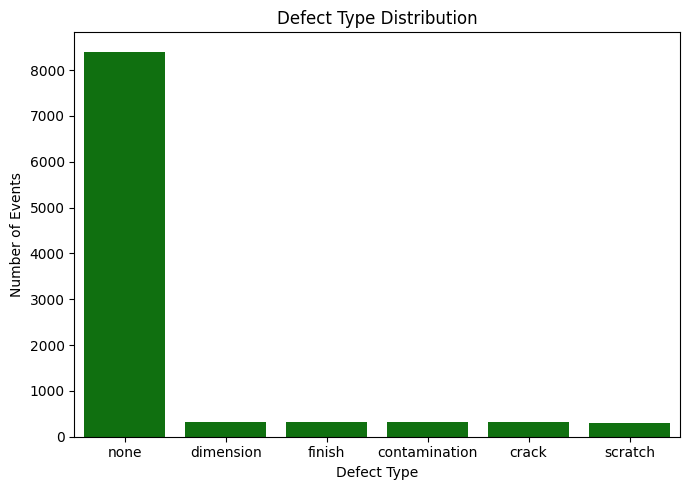

In [186]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x='defect_type',
    color='g',
    order=df['defect_type'].value_counts().index
  )

plt.title('Defect Type Distribution')
plt.xlabel('Defect Type')
plt.ylabel('Number of Events')
#plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

Description:
Visualizes the frequency of each defect type.

### **32. Monthly Defect Trend**

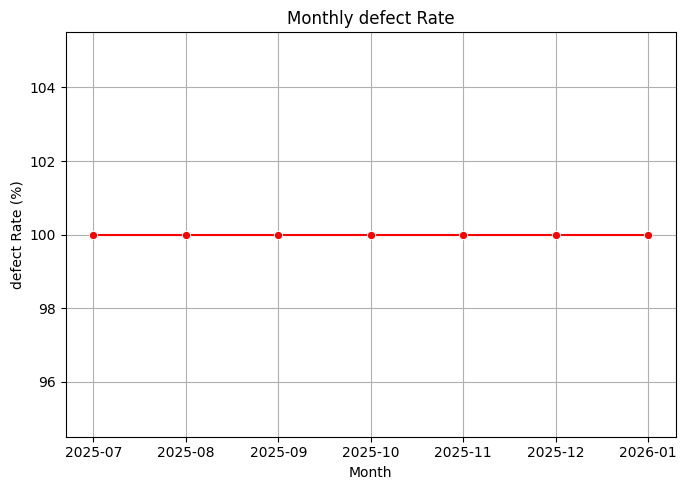

In [187]:
plt.figure(figsize=(7,5))

sns.lineplot(
    data=monthly_analysis.reset_index(),
    x='month',
    y='defect_rate',
    color='r',
    marker='o'
)
plt.title('Monthly defect Rate')
plt.xlabel('Month')
plt.ylabel('defect Rate (%)')
plt.grid()
# plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Description:
Shows how the defect rate changes month by month.

### **33. Scrap Rate by production Line**

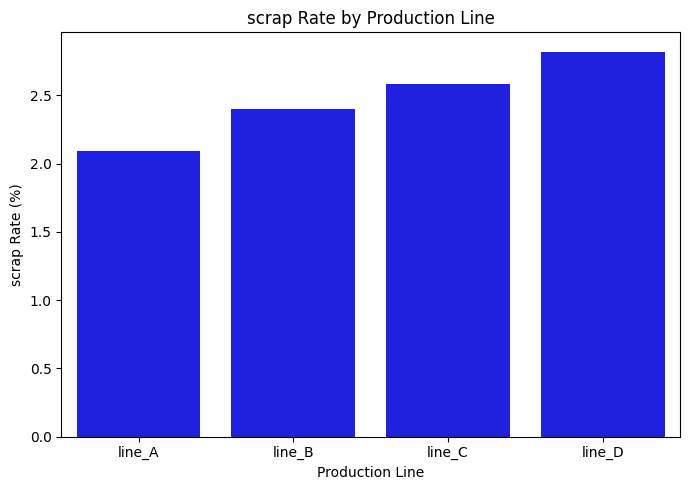

In [188]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=line_analysis.reset_index(),
    x='line',
    y='scrap_rate',
    color='b'
)

plt.title('scrap Rate by Production Line')
plt.xlabel('Production Line')
plt.ylabel('scrap Rate (%)')

plt.tight_layout()
plt.show()

Description:
Compares scrap rates between production lines.

### **34. Defect Rate by Material Grade**

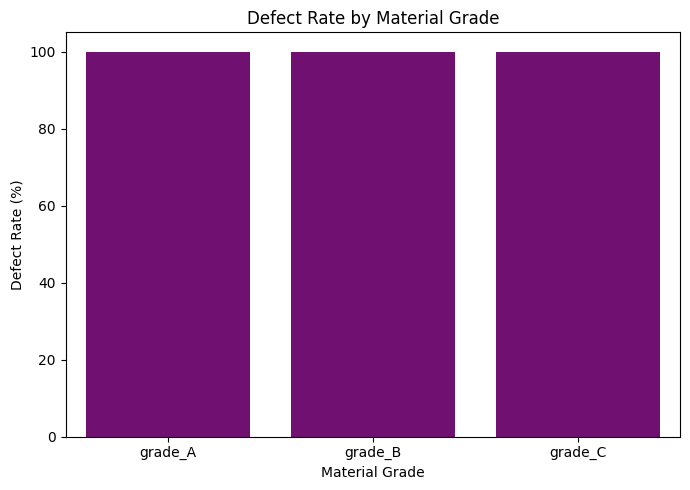

In [189]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=material_analysis.reset_index(),
    x='material_grade',
    y='defect_rate',
    color='purple',
)

plt.title('Defect Rate by Material Grade')
plt.xlabel('Material Grade')
plt.ylabel('Defect Rate (%)')

plt.tight_layout()
plt.show()

Description:
Compares defect rates across material grades.

### **35. Final Pass Rate by Shift**

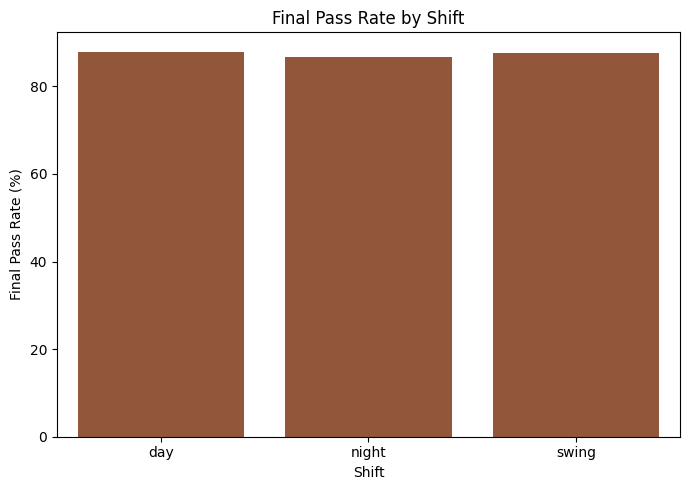

In [190]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=shift_analysis.reset_index(),
    x='shift',
    y='pass_rate',
    color='sienna'

)
plt.title('Final Pass Rate by Shift')
plt.xlabel('Shift')
plt.ylabel('Final Pass Rate (%)')

plt.tight_layout()
plt.show()

Description:
Shows the final inspection pass rate for each production shift.

### **36. Average Cost by Defect Severity**

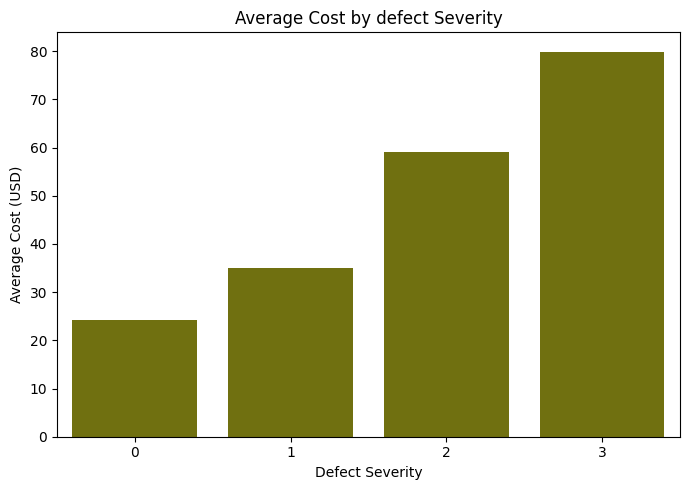

In [191]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=severity_analysis.reset_index(),
    x='defect_severity_0to3',
    y='average_cost',
    color='olive'
)

plt.title('Average Cost by defect Severity')
plt.xlabel('Defect Severity')
plt.ylabel('Average Cost (USD)')

plt.tight_layout()
plt.show()

Description:
Shows how average manufacturing cost changes across defect severity levels.

### **37. Correlation Heatmap**

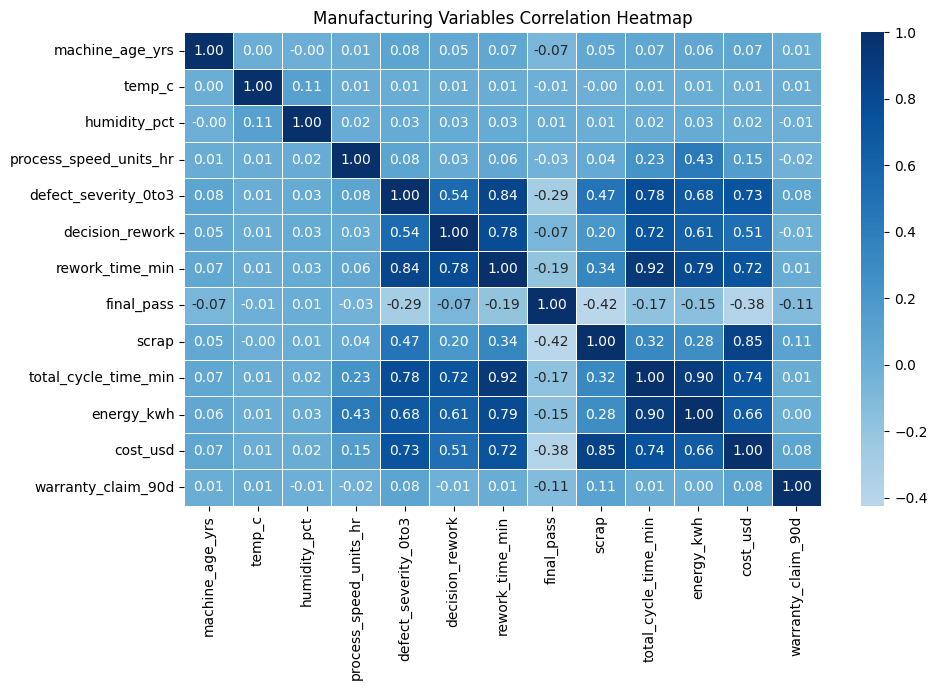

In [192]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    center=0,
    linewidth=0.5
)

plt.title('Manufacturing Variables Correlation Heatmap')

plt.tight_layout()
plt.show()

Description:
Provides a visual overview of relationships among numerical manufacturing variables.

### **38. Defect Rate by Plant**

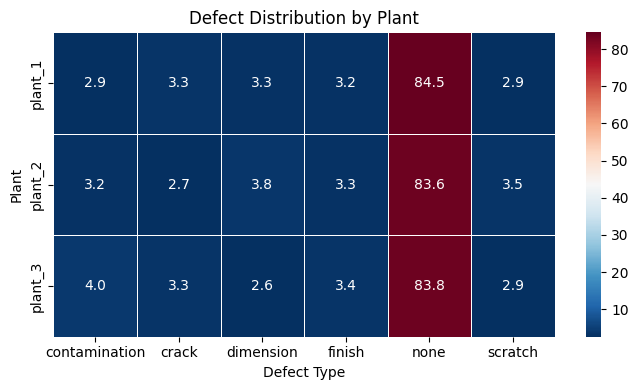

In [193]:
plant_defect = pd.crosstab(
    df["plant"],
    df["defect_type"],
    normalize="index"
) * 100

plt.figure(figsize=(7, 4))

sns.heatmap(
    plant_defect,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    linewidths=0.5
)

plt.title("Defect Distribution by Plant")
plt.xlabel("Defect Type")
plt.ylabel("Plant")

plt.tight_layout()
plt.show()

### **39. Temperature vs Defect Severity**

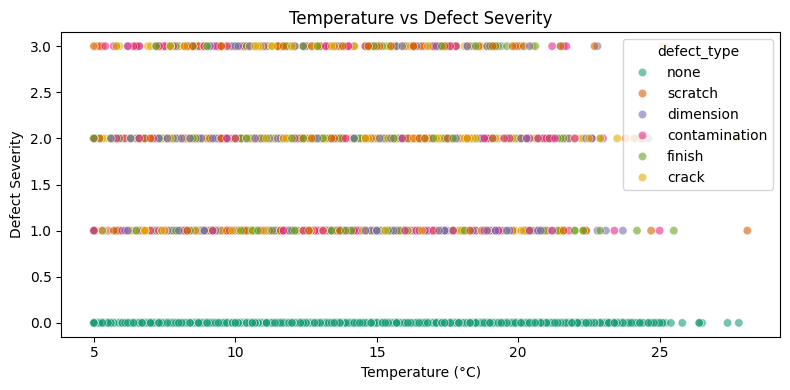

In [194]:
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=df,
    x="temp_c",
    y="defect_severity_0to3",
    hue="defect_type",
    alpha=0.6,
    palette='Dark2'
)

plt.title("Temperature vs Defect Severity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Defect Severity")

plt.tight_layout()
plt.show()

Helps investigate whether process temperature is associated with defect severity.

### **40. Machine Age vs Scrap**

/tmp/ipykernel_834/2927899623.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


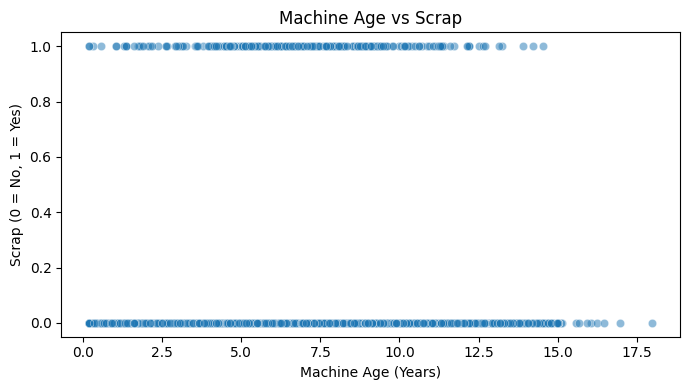

In [195]:
plt.figure(figsize=(7, 4))

sns.scatterplot(
    data=df,
    x="machine_age_yrs",
    y="scrap",
    palette='Dark2',
    alpha=0.5
)

plt.title("Machine Age vs Scrap")
plt.xlabel("Machine Age (Years)")
plt.ylabel("Scrap (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()

whether machine age is associated with scrap events.

### **41. Export Analysis Results**

In [196]:
plant_analysis.to_csv('plant_quality_analysis.csv')

line_analysis.to_csv('line_quality_analysis.csv')

shift_analysis.to_csv('shift_quality_analysis.csv')

material_analysis.to_csv('material_quality_analysis.csv')

inspection_analysis.to_csv('inspection_quality_analysis.csv')

severity_analysis.to_csv('severity_analysis.csv')

monthly_analysis.to_csv('monthly_quality_analysis.csv')

correlation_matrix.to_csv('correlation_matrix.csv')

severity_analysis.to_csv('severity_quality_analysis.csv')

monthly_analysis.to_csv('monthly_quality_analysis.csv')

Description:
Saves the major analysis results as CSV files so they can be reused in Excel, Power BI or a portfolio project.

### **42. Final Project Summary**

In [197]:
print('\n' + '=' * 50)
print('MANUFACTURING QUALITY ANALYSIS - FINAL SUMMARY')
print("=" * 50)

print(f'Total Manufacturing Events: {total_events:,}')
print(f'Defect Rate: {defect_rate:.2f}%')
print(f'Final Pass Rate: {pass_rate:.2f}%')
print(f'Scrap Rate: {scrap_rate:.2f}%')
print(f'Rework Rate: {rework_rate:.2f}%')
print(f'Warranty Claims Rate: {warranty_claim_rate:.2f}%')
print(f'Average Cycle Time: {average_cycle_time:.2f} minutes')
print(f'Average Energy Consumption: {average_energy:,.3f} kWh')
print(f'Average Cost: ${average_cost:,.2f}')


MANUFACTURING QUALITY ANALYSIS - FINAL SUMMARY
Total Manufacturing Events: 10,000
Defect Rate: 100.00%
Final Pass Rate: 87.61%
Scrap Rate: 2.48%
Rework Rate: 24.34%
Warranty Claims Rate: 1.25%
Average Cycle Time: 34.52 minutes
Average Energy Consumption: 1.422 kWh
Average Cost: $29.04
